# Tema 3.3 – Gráficos de Resumen (World Happiness 2015–2024)

En este notebook construiremos **gráficos de resumen** que nos permitan visualizar:
- Distribución de la felicidad.
- Comparación entre regiones.
- Cambios a través del tiempo.

## Pregunta guía principal
**¿Cómo se visualizan las diferencias en felicidad entre regiones y a lo largo del tiempo?**

Los gráficos nos permiten ver patrones que son difíciles de notar solo con tablas.


## 0. Carga y preparación del dataset
Este bloque garantiza que el notebook sea autónomo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)


In [2]:
# =========================
# 0.2 Cargar y unificar los datasets 2015–2024
# =========================

years = range(2015, 2025)  # 2015 a 2024
dfs = [] #esto va a ser una lista de df

for year in years:
    file_name = f"./data/world_happiness_{year}.csv"  # Ajusta el nombre si es necesario

    df_year = pd.read_csv(
        file_name,
        sep=";",              # Los archivos usan ';' como separador
        engine="python",      # Motor más flexible
        on_bad_lines="skip"    # Ignora filas defectuosas para evitar errores
    )

    df_year["Year"] = year
    dfs.append(df_year)

df = pd.concat(dfs, ignore_index=True)

df.head(10)

,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Switzerland,Western Europe,7.59,8.26,0.96,73.0,0.99,0.37,0.24,2015
1,2,Iceland,Western Europe,7.56,7.70,1.00,73.0,0.94,0.55,0.74,2015
2,3,Denmark,Western Europe,7.53,7.84,0.97,70.0,0.97,0.43,0.12,2015
3,4,Norway,Western Europe,7.52,8.63,0.95,71.0,1.00,0.44,0.34,2015
4,5,Canada,North America and ANZ,7.43,7.85,0.94,71.0,0.95,0.58,0.40,2015
5,6,Finland,Western Europe,7.41,7.63,0.94,71.0,0.96,0.29,0.25,2015
6,7,Netherlands,Western Europe,7.38,7.86,0.91,71.0,0.92,0.60,0.42,2015
7,8,Sweden,Western Europe,7.36,7.88,0.92,72.0,0.99,0.46,0.21,2015
8,9,New Zealand,North America and ANZ,7.29,7.40,0.94,72.0,0.95,0.60,0.22,2015
9,10,Australia,North America and ANZ,7.28,7.89,0.93,72.0,0.97,0.55,0.35,2015


In [9]:
# =========================
# 0.3 Crear columna numérica de felicidad y renombrar columnas
# =========================

df["Happiness_score_num"] = (
    df["Happiness score"].astype(str).str.replace(",", ".", regex=False)
)
df["Happiness_score_num"] = pd.to_numeric(df["Happiness_score_num"], errors="coerce")

df = df.rename(columns={
    "Regional indicator": "Region",
    "GDP per capita": "GDP_per_capita",
    "Social support": "Social_support",
    "Healthy life expectancy": "Healthy_life_expectancy",
    "Freedom to make life choices": "Freedom",
    "Perceptions of corruption": "Corruption",
})

df.head()

,Ranking,Country,Region,Happiness score,GDP_per_capita,Social_support,Healthy_life_expectancy,Freedom,Generosity,Corruption,Year,Happiness_score_num
0,1,Switzerland,Western Europe,7.59,8.26,0.96,73.0,0.99,0.37,0.24,2015,7.59
1,2,Iceland,Western Europe,7.56,7.70,1.00,73.0,0.94,0.55,0.74,2015,7.56
2,3,Denmark,Western Europe,7.53,7.84,0.97,70.0,0.97,0.43,0.12,2015,7.53
3,4,Norway,Western Europe,7.52,8.63,0.95,71.0,1.00,0.44,0.34,2015,7.52
4,5,Canada,North America and ANZ,7.43,7.85,0.94,71.0,0.95,0.58,0.40,2015,7.43


## 1. Histogramas – Distribución de la Felicidad

Los histogramas nos muestran qué tan **concentrados** o **dispersos** están los valores de felicidad.

### ¿Qué buscamos responder aquí?
- ¿La felicidad se concentra alrededor de valores medios?
- ¿Hay colas largas (muchos países muy infelices o muy felices)?


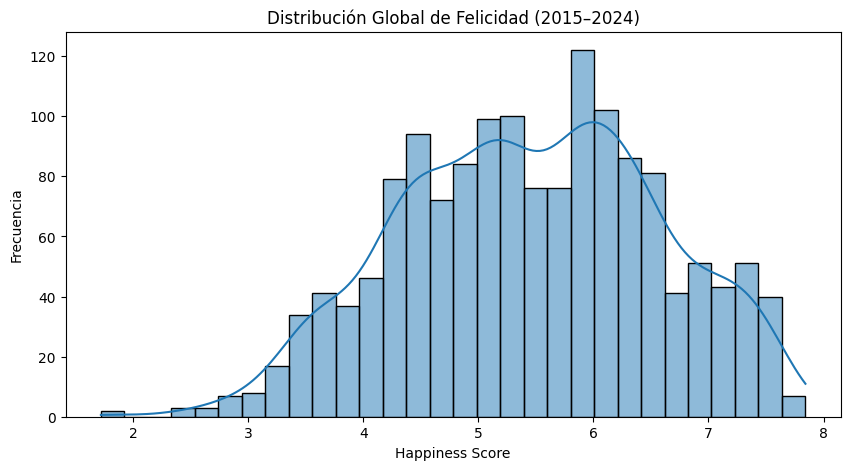

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(df['Happiness_score_num'],bins=30,kde=True)
plt.title('Distribución Global de Felicidad (2015–2024)')
plt.xlabel('Happiness Score')
plt.ylabel('Frecuencia')
plt.show()

### Interpretación
La mayoría de países se concentran entre **4.5 y 6.5**, lo que confirma que el nivel global de felicidad tiende a ser medio.


## 2. Boxplots – Comparación entre Regiones

Los boxplots permiten comparar diferencias entre regiones.

### Pregunta clave
**¿Qué regiones presentan mayor dispersión y cuáles son consistentemente más felices?**


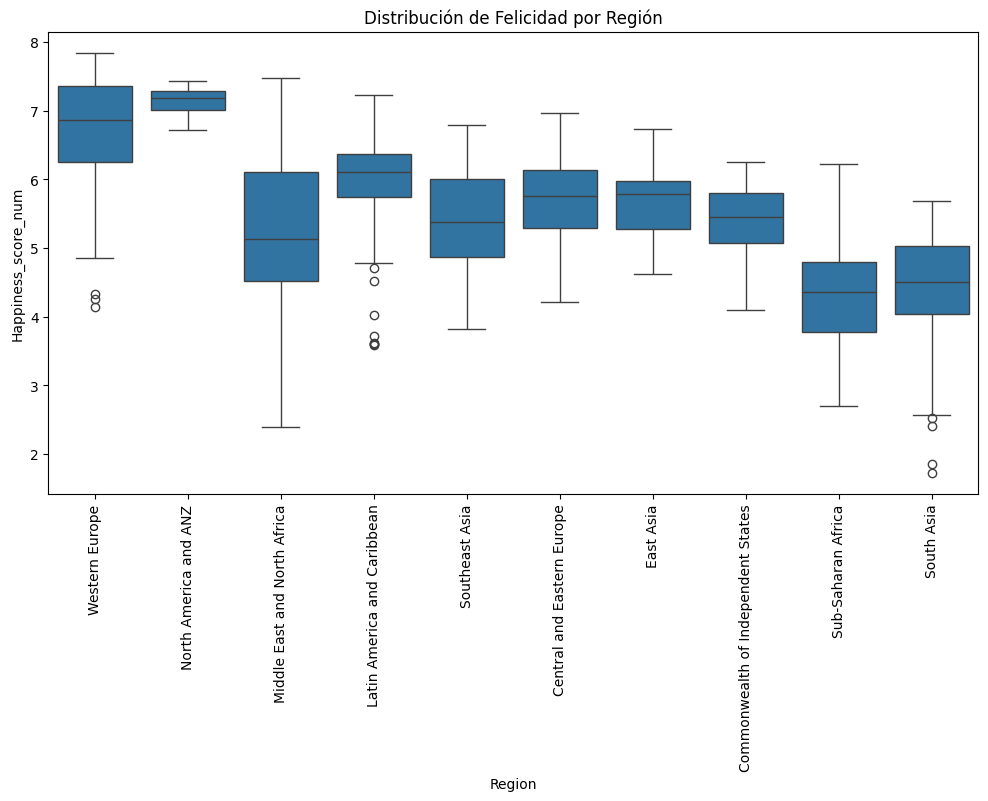

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x='Region',y='Happiness_score_num')
plt.xticks(rotation=90)
plt.title('Distribución de Felicidad por Región')
plt.show()

### Interpretación
- *North America and ANZ* y *Western Europe* presentan medianas muy altas.
- *Sub-Saharan Africa* y *South Asia* tienden a estar en los valores más bajos.


## 3. Gráfico de Barras – Felicidad Promedio por Región


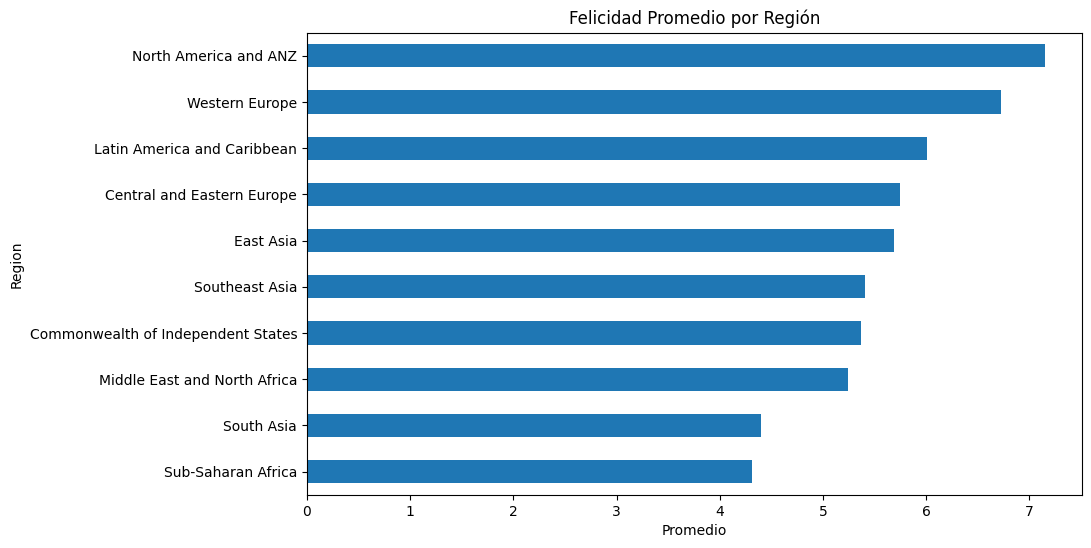

In [12]:
region_mean=df.groupby('Region')['Happiness_score_num'].mean().sort_values()
plt.figure(figsize=(10,6))
region_mean.plot(kind='barh')
plt.title('Felicidad Promedio por Región')
plt.xlabel('Promedio')
plt.show()

### Insights
Las diferencias son claras: regiones desarrolladas lideran, mientras otras se rezagan.


## 4. Línea temporal – Felicidad promedio por año
Visualiza cómo ha cambiado la felicidad global con el tiempo.

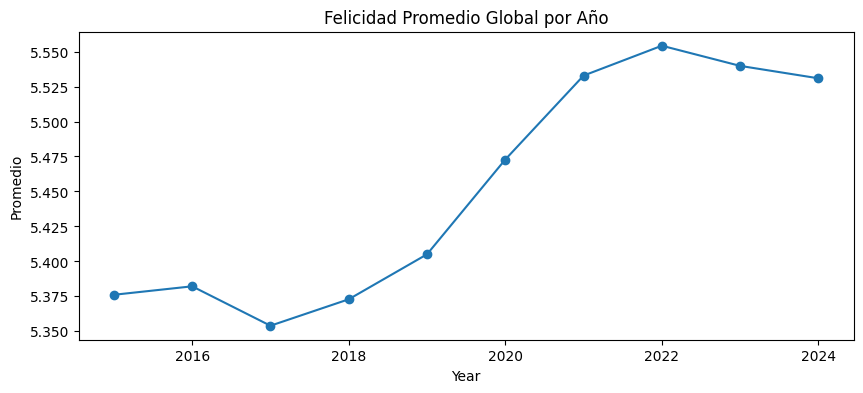

In [13]:
year_mean=df.groupby('Year')['Happiness_score_num'].mean()
year_mean.plot(figsize=(10,4),marker='o')
plt.title('Felicidad Promedio Global por Año')
plt.ylabel('Promedio')
plt.show()

### Interpretación
La tendencia es **ligeramente al alza**, aunque estable.


## 5. Tu turno – Ejercicios

### Ejercicio 1 – Histograma por región
Construye un histograma **para una región específica**.

### Ejercicio 2 – Boxplot por año
Grafica un boxplot de felicidad para un año a elección.

### Ejercicio 3 – Barras agrupadas
Comparar dos regiones en felicidad promedio usando barras lado a lado.
